<table class="tfo-notebook-buttons" align="left">
<td style="border: none;">
<a target="blank" href="https://colab.research.google.com/github/Hari31416/Portfolio/blob/main/Titanic/Models%20I.ipynb?hl=en"><img src="https://colab.research.google.com/img/colab_favicon_256px.png" width="28" height="28"/>Run on Google Colab</a></td>
<td style="border: none;">
<a target="blank" href="https://github.com/Hari31416/Portfolio/blob/main/Titanic/Models%20I.ipynb"><img src="https://cdn.icon-icons.com/icons2/2368/PNG/512/github_logo_icon_143772.png" width="28" height="28"/>View on Github</a></td>
<td style="border: none;">
</table>

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## loading the data

In [2]:
train = pd.read_csv('train_final.csv')
test = pd.read_csv('test_final.csv')

In [3]:
train.head()

,Survived,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,0,3,0,1,0,2,0,1,0,0,...,0,1,0,0,0,0,0,1,-0.565587,-0.502445
1,1,1,1,1,0,2,0,0,0,0,...,0,1,0,1,0,0,0,0,0.624229,0.786845
2,1,3,1,0,0,1,0,1,0,1,...,0,1,0,0,0,0,0,1,-0.268133,-0.488854
3,1,1,1,1,0,2,0,1,0,0,...,0,0,0,1,0,0,0,0,0.401138,0.420730
4,0,3,0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,1,0.401138,-0.486337


In [4]:
test.head()

,Pclass,Sex,SibSp,Parch,FamilySize,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,...,Ticket_first_letter_7,Ticket_first_letter_X,Cabin_First_B,Cabin_First_C,Cabin_First_D,Cabin_First_E,Cabin_First_F,Cabin_First_N,Age,Fare
0,3,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,0.337221,-0.497350
1,3,1,1,0,2,0,1,0,0,0,...,0,0,0,0,0,0,0,1,1.302134,-0.512214
2,2,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,1,2.460031,-0.464037
3,3,0,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,1,-0.241727,-0.482412
4,3,1,1,1,3,0,1,0,0,0,...,0,0,0,0,0,0,0,1,-0.627692,-0.417429


In [5]:
columns = test.columns
columns

Index(['Pclass', 'Sex', 'SibSp', 'Parch', 'FamilySize', 'Embarked_Q',
       'Embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs',
       'Title_Other', 'Title_Rev', 'Ticket_first_letter_2',
       'Ticket_first_letter_3', 'Ticket_first_letter_4',
       'Ticket_first_letter_6', 'Ticket_first_letter_7',
       'Ticket_first_letter_X', 'Cabin_First_B', 'Cabin_First_C',
       'Cabin_First_D', 'Cabin_First_E', 'Cabin_First_F', 'Cabin_First_N',
       'Age', 'Fare'],
      dtype='object')

In [6]:
X = train.drop(['Survived'], axis=1).values
y = train['Survived'].values

### Creating the train and test data

In [7]:
len(X)

891

Since there are just 891 rows in the train data, we will use a test size of 0.25 to create the test data.

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [9]:
len(X_train),len(X_test)

(668, 223)

## Modeling

### Procedure

Since we have already standardized the data, we'll jump directly to the model creation. We'll start from the simplest, `LinearRegression` and keep on increasing the complexity until we get a good model. The process will be as follows:
1. Create a model using default parameters
2. Fit the model to the training data and get model performance
3. Create a `GridSearchCV` object to find the best parameters for the model
4. Fit the model to the training data and get model performance
5. Repeat steps 1-4 for different models

Since this is a classification problem, the models we'll use are:
1. `LogisticRegression`
2. `KNeighborsClassifier`
3. `SVC`
4. `DecisionTreeClassifier`
5. `RandomForestClassifier`
6. `GaussianNB`
7. `GradientBoostingClassifier`
8. `XGBClassifier`
9. `BaggingClassifier`
10. `AdaBoostClassifier`
11. `ExtraTreesClassifier`

...and more( if I can find them!).

With every model, I'll briefly describe the parameters that we'll be using. If we created all these models in a single notebook, it will be huge. So I'll create a number of notebooks.

To keeptrack of various models and their performance, I'll create a dictionary with model name as key and a dictionary of performance metrics as values.

### Performance Metrics

In previous notebook, we saw that this classification is not perfectly balanced as only about 39% passengers survived. So `accuracy` is not that good a metric. However, we'll be using accuracy along with `precision`, `recall`, `f1_score` and  `roc_auc_score` to evaluate the model performance. These are the parameters, we'll be saving in the dictionary. We'll also plot the confusion matrix and ROC curve. So, the metrics we'll be saving in the dictionary are:
1. `accuracy`
2. `precision`
3. `recall`
4. `f1_score`
5. `roc_auc_score`

Let's create some helper functions.

### Helper Functions

I'll be using the `shelve` module to save the dictionary. The dictionary is loaded in the code cell below and given the name `models_performance`. 

In [148]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from life_saving_tools import Notification
from sklearn.model_selection import GridSearchCV
import shelve
n = Notification.Notification()
params = {}

def load_performance_dict(file = 'models_performance.shelve'):
    """
    This function loads the performance of a model from the `model_performance` \\
        dictionary.

    Parameters
    ----------
    model_name : string
        the name of the model to load from the `model_performance` dictionary

    Returns
    -------
    model_performance : dictionary
    """
    shelve_file = shelve.open(file)

    try:
        models_performance = shelve_file['models_performance']
    except:
        models_performance = {}

    shelve_file.close()
    return models_performance

models_performance = load_performance_dict()

def save_performance_dict(file = 'models_performance.shelve', dict = models_performance):
    """
    This function saves the model_performance dictionary to a shelve file.

    Parameters
    ----------
    file : string
        the name of the shelve file to save the dictionary to

    Returns
    -------
    None
    """
    shelve_file = shelve.open(file)
    shelve_file['models_performance'] = models_performance
    shelve_file.close()

def perform_grid_search(model, params = params, X= X_train, y=y_train, 
    notify = True, cv = 5, scoring = 'roc_auc', verbose = 1):
    """
    Performs grid serach on the model and returns the best model with parameters.

    Parameters
    ----------
    model : sklearn model

    X : training data
        defualt is X_train

    y : target data
        defualt is y_train

    params : dictionary
        the parameters to search over
        defualt is params

    notify : boolean
        if True, a notification is sent to whatsapp
        defualt is True

    cv : number of folds for cross validation
        defualt is 5

    scoring : scoring metric
        defualt is 'roc_auc'

    verbose : verbosity level
        defualt is 1

    Returns
    -------
    grid_search : sklearn GridSearchCV object
    """
    grid = GridSearchCV(model, params, cv=cv, scoring=scoring, verbose=verbose)
    grid.fit(X, y)

    best_estimator = grid.best_estimator_
    best_params = grid.best_params_
    best_score = grid.best_score_
    text = f"""Following is the best model and its parameters:
        Best Model:\n{best_estimator}\nBest params:
        \n{best_params}\nBest score: {best_score}"""
    
    if notify:
        n.send_whatsapp_text(text)
    print(text)
    return grid

def visualize_model(model, features = X_test):
    """
    This function plots the confusion metrics and classification report

    Parameters
    ----------
    model : sklearn model

    Returns
    -------
    None
    """
    #predicting on the data
    y_pred = model.predict(features)
    
    #Printing the classification report
    print(classification_report(y_test, y_pred))
    
    #Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

def evaluate_model(model, model_name = None, final = False):
    """
    The function takes a model as input and creats a dictionary with the model's \\
        accuracy, precision, recall, f1 score, and roc_auc_score and add them to the \\
        `model_performance` dictionary and returns it. The `model_performance` dictionary \\
        is instantiated just before this function is created.

    Parameters
    ----------
    model : sklearn model

    model_name : string
        the name of the model to store as a key in the `model_performance` dictionary

    final : boolean
        if True, the scores are added to the `model_performance` dictionary as well

    Returns
    -------
    model_performance : dictionary
    """
    #Making predictions on the test set
    y_pred = model.predict(X_test)

    #Getting the metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    if final:
    #Adding the metrics to the model_performance dictionary
        if model_name is None:
            model_name = type(model).__name__

        models_performance[model_name] = {
                'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}
        return models_performance[model_name]
    else:
        return {'accuracy': accuracy, 'precision': precision, 
                'recall': recall, 'f1': f1, 'roc_auc': roc_auc}

## Logistics Regression

### Basic Parameters

In [139]:
from sklearn.linear_model import LogisticRegression

lr_base = LogisticRegression()
lr_base.fit(X_train, y_train)

LogisticRegression()

In [140]:
evaluate_model(lr_base, 'lr_base', final = True)

{'accuracy': 0.8026905829596412,
 'precision': 0.7472527472527473,
 'recall': 0.7640449438202247,
 'f1': 0.7555555555555554,
 'roc_auc': 0.7962015763877244}

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       134
           1       0.75      0.76      0.76        89

    accuracy                           0.80       223
   macro avg       0.79      0.80      0.80       223
weighted avg       0.80      0.80      0.80       223



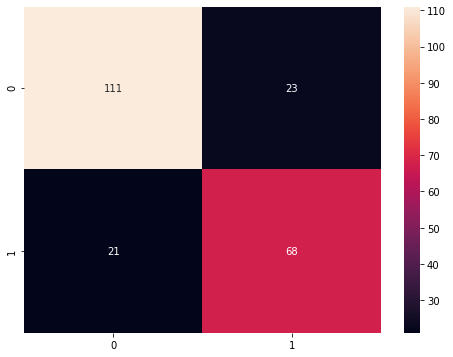

In [141]:
visualize_model(lr_base)

### Finding the best parameters

#### Parameters
* `C`: Inverse of regularization strength; must be a positive float. Like in SVM, smaller values specify stronger regularization.
* `fit_intercept`: bool, default True. Whether to calculate the intercept for this model. If set to false, no intercept will be used in calculations (e.g. data is expected to be already centered).
* `penalty`: {‘l1’, ‘l2’, ‘elasticnet’}, default ‘l2’. The penalty to be used.
* `solver`: {‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’}, default 'lbfgs'. Algorithm to use in the optimization problem.

#### Running GridSearchCV

I'll be using the training data during `GridSearchCV`. After that, I'll be using the best parameters to create the model, fit it and evaluate it on test data. The number of folds will be 3.

In [150]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')
params = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2', 'elasticnet'],
            'fit_intercept': [True, False], 'l1_ratio': [0, 0.1, 0.5, 0.9, 1]}

lr_base = LogisticRegression(solver='saga', random_state=42, max_iter=10000)
grid_1 = perform_grid_search(lr_base, params)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 750 out of 750 | elapsed:  3.8min finished


SMad02daa81cb6454d9f2564a84597da62
Following is the best model and its parameters:
        Best Model:
LogisticRegression(C=1, l1_ratio=0.9, max_iter=10000, penalty='elasticnet',
                   random_state=42, solver='saga')
Best params:
        
{'C': 1, 'fit_intercept': True, 'l1_ratio': 0.9, 'penalty': 'elasticnet'}
Best score: 0.8684923222300969


In [151]:
evaluate_model(grid_1.best_estimator_)

{'accuracy': 0.820627802690583,
 'precision': 0.7692307692307693,
 'recall': 0.7865168539325843,
 'f1': 0.7777777777777778,
 'roc_auc': 0.8149002180110683}

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       134
           1       0.77      0.79      0.78        89

    accuracy                           0.82       223
   macro avg       0.81      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223



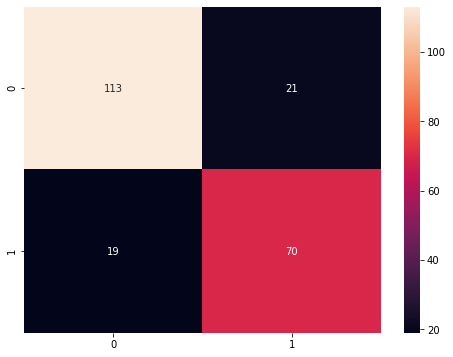

In [152]:
visualize_model(grid_1.best_estimator_)

Let's narrow down the parameters search for grid search and see if we can beat the above parameters.

In [153]:
params = {'C': [0.5, 0.7, 1, 1.2, 1.5], 'penalty': ['elasticnet'],
        "l1_ratio": [0.3, 0.6, 0.9, 1.2, 1.5]}

grid_2 = perform_grid_search(lr_base, params)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 125 out of 125 | elapsed:   19.2s finished


SM8258fff2900e48c8bd371ebda6fa13af
Following is the best model and its parameters:
        Best Model:
LogisticRegression(C=1.5, l1_ratio=0.9, max_iter=10000, penalty='elasticnet',
                   random_state=42, solver='saga')
Best params:
        
{'C': 1.5, 'l1_ratio': 0.9, 'penalty': 'elasticnet'}
Best score: 0.8698417198204582


In [154]:
evaluate_model(grid_2.best_estimator_)

{'accuracy': 0.8161434977578476,
 'precision': 0.7666666666666667,
 'recall': 0.7752808988764045,
 'f1': 0.7709497206703911,
 'roc_auc': 0.8092822404829784}

Not any change at all. I think we should be satisfied with the previous parameters.

In [155]:
evaluate_model(grid_1.best_estimator_, 'lr_gs_final', final = True)

{'accuracy': 0.820627802690583,
 'precision': 0.7692307692307693,
 'recall': 0.7865168539325843,
 'f1': 0.7777777777777778,
 'roc_auc': 0.8149002180110683}

Just one correct classification more than the base model.

In [158]:
save_performance_dict()

## KNeighborsClassifier

### Basic Parameters

In [159]:
from sklearn.neighbors import KNeighborsClassifier
knc_base = KNeighborsClassifier()

knc_base.fit(X_train, y_train)

KNeighborsClassifier()

In [160]:
evaluate_model(knc_base, 'knc_base', final = True)

{'accuracy': 0.8161434977578476,
 'precision': 0.7790697674418605,
 'recall': 0.7528089887640449,
 'f1': 0.7657142857142858,
 'roc_auc': 0.8055089719939627}

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       134
           1       0.78      0.75      0.77        89

    accuracy                           0.82       223
   macro avg       0.81      0.81      0.81       223
weighted avg       0.82      0.82      0.82       223



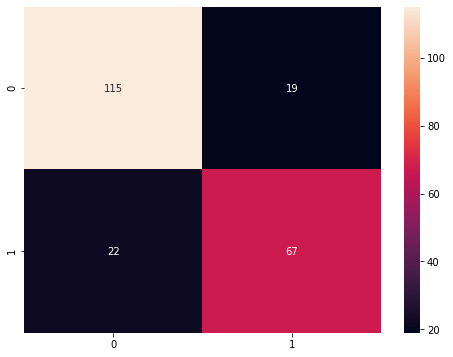

In [161]:
visualize_model(knc_base)

### Finding the best parameters

#### Parameters

The parameters for KNeighborsClassifier are:
* `n_neighbors`: int, default 5. Number of neighbors to use by default for kneighbors queries.
* `weights`: {‘uniform’, ‘distance’}, default ‘uniform’. Method of weighting the KNeighborsClassifier.
* `algorithm`: {‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’}, default ‘auto’. Algorithm used to compute the nearest neighbors.
* `leaf_size`: int, default 30. Leaf size passed to BallTree or KDTree. This can affect the speed of the construction and query, as well as the memory required to store the tree.
* `p`: int, default 2. Parameter for the Minkowski metric from sklearn.metrics.pairwise.pairwise_distances. When p = 1, this is equivalent to using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.


In [ ]:
params = {"n_neighbors":[4,5,6,8,10,15,20], "weights":['uniform', 'distance'], 
    "algorithm":['auto', 'ball_tree', 'kd_tree', 'brute'],
    "leaf_size": [20, 30, 40, 50, 60, 70], "p": [1, 2]}

base_model = KNeighborsClassifier()
grid = GridSearchCV(base_model, params, cv=3, scoring='roc_auc')
grid_3 = perform_grid_search(grid, params)